# 05 · TabPFN as the filter inside my live strategy (features withheld)

My live 15-minute strategy fires a directional signal and then asks a **gate** model whether to take
it. The live gate is a LightGBM model trained once on spring data. Here every candidate gate scores the
same **1,494 out-of-sample signals**. They come from three 30-day blocks between 14 July and 2 October,
each trained on the previous 90 days.

The 32 input features, the thresholds, the entry window and the exit rules are private. This file holds
only each model's score, which trades each rule took, and the realised outcome per contract:
`data/strategy/oos_predictions.parquet`.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tabtrader import plots
plots.style()
pd.set_option("display.width", 140, "display.max_columns", 30)

In [2]:
d = pd.read_parquet(ROOT / "data" / "strategy" / "oos_predictions.parquet")
print(len(d), "signals,", d.day.nunique(), "days")
d.head()

1494 signals, 78 days


,day,block,won,net_c_hold,net_c_exits,take__live,p__live_gate,p__price,take__price__threshold,take__price__edge,p__logistic,take__logistic__threshold,take__logistic__edge,p__ensemble_lr_lgbm_xgb,take__ensemble_lr_lgbm_xgb__threshold,...,p__lstm_btc_bars,take__lstm_btc_bars__threshold,take__lstm_btc_bars__edge,p__lstm_bars_plus_state,take__lstm_bars_plus_state__threshold,take__lstm_bars_plus_state__edge,p__stack,take__stack__threshold,take__stack__edge,p__tabpfn,take__tabpfn__threshold,take__tabpfn__edge,p__tabpfn_plus_momentum,take__tabpfn_plus_momentum__threshold,take__tabpfn_plus_momentum__edge
0,2026-07-14,0,1,32.0,-12.0,False,0.19813,0.66,False,False,0.76362,False,False,0.69717,False,...,0.62117,False,False,0.66963,False,False,0.61354,False,False,0.70719,False,False,0.70418,False,False
1,2026-07-14,0,0,-52.0,-52.0,False,0.02610,0.50,False,False,0.58532,False,False,0.62393,False,...,0.60515,False,True,0.54474,False,False,0.48541,False,False,0.59406,False,True,0.58901,False,True
2,2026-07-14,0,1,56.0,56.0,False,0.11981,0.42,False,False,0.57557,False,True,0.58226,False,...,0.62816,False,True,0.54458,False,False,0.43842,False,False,0.47837,False,False,0.45980,False,False
3,2026-07-14,0,1,51.0,51.0,False,0.22021,0.47,False,False,0.52946,False,False,0.54272,False,...,0.69473,False,True,0.57156,False,False,0.44899,False,False,0.50301,False,False,0.50646,False,False
4,2026-07-14,0,1,20.0,20.0,True,0.44511,0.78,False,False,0.91246,True,True,0.82528,False,...,0.60191,False,False,0.75173,False,False,0.74004,False,False,0.79165,False,False,0.76684,False,False


### Which model ranks winners best? (AUC, with day-block 95% CIs vs the market price)

In [3]:
from sklearn.metrics import roc_auc_score
from tabtrader.evaluate import day_weights
names = {"price": "market price", "live_gate": "live gate (current)", "logistic": "logistic regression",
         "ensemble_lr_lgbm_xgb": "LR + LightGBM + XGBoost", "mlp": "MLP", "lstm_btc_bars": "LSTM on BTC bars",
         "lstm_bars_plus_state": "LSTM + contract state", "stack": "stack", "tabpfn": "TabPFN-3.5",
         "tabpfn_plus_momentum": "TabPFN-3.5 + momentum summary"}
rng = np.random.default_rng(0); days = d.day.unique()
idx = {k: np.where(d.day.values == k)[0] for k in days}
boots = [np.concatenate([idx[k] for k in rng.choice(days, len(days))]) for _ in range(1000)]
y = d.won.values; pp = d.p__price.values
rows = []
for k, lab in names.items():
    p = d[f"p__{k}"].values
    diffs = [roc_auc_score(y[b], p[b]) - roc_auc_score(y[b], pp[b]) for b in boots]
    rows.append({"model": lab, "AUC": roc_auc_score(y, p), "Δ vs price": np.mean(diffs),
                 "lo": np.percentile(diffs, 2.5), "hi": np.percentile(diffs, 97.5)})
auc = pd.DataFrame(rows).set_index("model").sort_values("AUC", ascending=False).round(4); auc

,AUC,Δ vs price,lo,hi
model,,,,
TabPFN-3.5 + momentum summary,0.7381,0.0098,-0.0009,0.0200
TabPFN-3.5,0.7365,0.0081,-0.0026,0.0180
logistic regression,0.7292,0.0011,-0.0164,0.0174
LR + LightGBM + XGBoost,0.7291,0.0009,-0.0131,0.0141
market price,0.7281,0.0000,0.0000,0.0000
MLP,0.7278,-0.0001,-0.0153,0.0151
stack,0.7229,-0.0051,-0.0184,0.0081
LSTM + contract state,0.7213,-0.0066,-0.0201,0.0077
live gate (current),0.6878,-0.0404,-0.0641,-0.0170


### Trading results: each gate's trades, ¢ per contract (with the live exits), paired against the live gate

In [4]:
ex = d.net_c_exits.values
live = d.take__live.values
B = len(boots)
def rule_stats(take):
    c = ex[take].mean()
    diffs = np.array([ex[b][take[b]].mean() - ex[b][live[b]].mean() for b in boots])
    daily = pd.Series(ex * take, index=d.day).groupby(level=0).sum().cumsum()
    dd = (daily - daily.cummax()).min()
    return {"trades": int(take.sum()), "¢/ct": c, "vs live": diffs.mean(),
            "lo": np.percentile(diffs, 2.5), "hi": np.percentile(diffs, 97.5),
            "total ¢ (1 ct)": ex[take].sum(), "max drawdown ¢": dd}
R = {"live gate (current)": rule_stats(live), "take every signal": rule_stats(np.ones(len(d), bool))}
for k, lab in names.items():
    for layer, ll in [("edge", "calibrated edge"), ("threshold", "threshold")]:
        col = f"take__{k}__{layer}"
        if col in d: R[f"{lab} · {ll}"] = rule_stats(d[col].values)
res = pd.DataFrame(R).T.sort_values("¢/ct", ascending=False).round(2); res

,trades,¢/ct,vs live,lo,hi,total ¢ (1 ct),max drawdown ¢
TabPFN-3.5 + momentum summary · calibrated edge,467.0,5.92,2.26,-0.16,4.46,2766.0,-200.0
LSTM + contract state · calibrated edge,516.0,5.81,2.18,-0.67,5.06,2999.0,-270.0
TabPFN-3.5 · calibrated edge,526.0,5.47,1.81,-0.19,3.83,2878.0,-308.0
MLP · calibrated edge,661.0,5.39,1.83,-0.53,4.43,3563.0,-298.0
LSTM on BTC bars · threshold,442.0,5.36,1.72,-0.97,4.50,2371.0,-147.0
logistic regression · calibrated edge,527.0,5.20,1.64,-1.28,4.33,2743.0,-302.0
LSTM on BTC bars · calibrated edge,591.0,4.49,0.88,-2.25,3.83,2654.0,-517.0
stack · calibrated edge,505.0,4.29,0.70,-2.27,3.74,2164.0,-324.0
LR + LightGBM + XGBoost · calibrated edge,648.0,4.09,0.47,-1.58,2.71,2651.0,-340.0
live gate (current),861.0,3.62,0.00,0.00,0.00,3119.0,-308.0


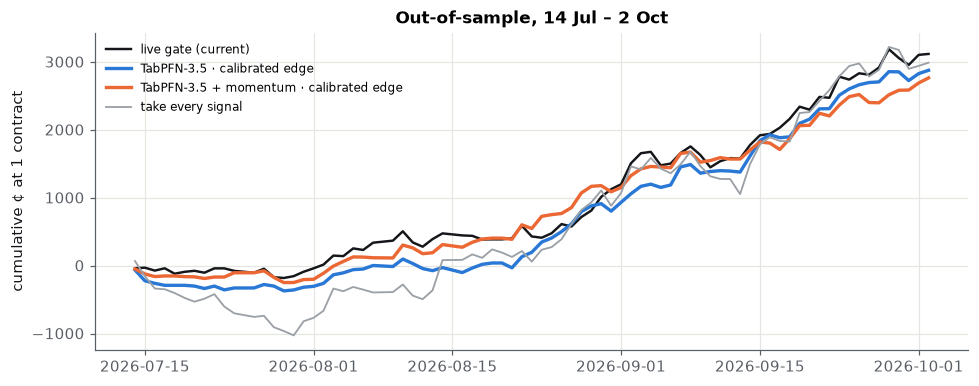

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for lab, take, col, lw in [("live gate (current)", live, plots.INK, 1.6),
                           ("TabPFN-3.5 · calibrated edge", d.take__tabpfn__edge.values, plots.TABPFN, 2.2),
                           ("TabPFN-3.5 + momentum · calibrated edge", d.take__tabpfn_plus_momentum__edge.values, plots.FAST, 2.2),
                           ("take every signal", np.ones(len(d), bool), plots.CLASSIC, 1.2)]:
    s = pd.Series(ex * take, index=pd.to_datetime(d.day)).groupby(level=0).sum().cumsum()
    ax.plot(s.index, s.values, color=col, lw=lw, label=lab)
ax.set_ylabel("cumulative ¢ at 1 contract"); ax.legend(fontsize=8); ax.set_title("Out-of-sample, 14 Jul – 2 Oct")
plt.tight_layout()

**Reading it honestly:**
- TabPFN is the best *ranker* of the ten approaches I tested. Its gain over the market price alone
  is small, and the confidence interval touches zero.
- As a calibrated-edge gate it lifts profit per contract over the live gate, mainly by taking fewer,
  better trades, which also shrinks drawdowns. The paired confidence intervals still include zero.
- These blocks were also used in earlier experiments, so the next step is a forward test on data no
  model has seen.

The case for TabPFN here is that it is the strongest ranker with **no tuning**, and it refits on a CPU
in under a minute. That makes weekly retraining cheap.